# Baseline com Batch Normalization — GTSRB
Exeperimento 2 - comparação da arquitetura Adam com e sem Batch Normalization

In [1]:
!pip install -q torch torchvision seaborn

### 1. SETUP

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
import copy
from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

In [27]:
model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
  os.mkdir(model_pth_path)

figs_path = '/content/figs2'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2.Hiperparâmetros

In [4]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 30
LR = 1e-3

In [5]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

100%|██████████| 187M/187M [00:08<00:00, 21.6MB/s]
100%|██████████| 89.0M/89.0M [00:06<00:00, 13.9MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 297kB/s]


Usando dispositivo: cpu


In [6]:
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"train_loader = {len(train_loader)} batches")
print(f"val_loader = {len(val_loader)} batches")
print(f"test_loader = {len(test_loader)} batches")

for x, y in train_loader:
    print("Formato das imagens:", x.shape)
    print("Formato dos rótulos:", y.shape)
    break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


NUM_CLASSES = 43
train_loader = 167 batches
val_loader = 42 batches
test_loader = 99 batches
Formato das imagens: torch.Size([128, 3, 32, 32])
Formato dos rótulos: torch.Size([128])


### 3.Modelo rede neural


### 3.1 Classe para Rede Neural COM Batch Normalization

In [7]:
class EHMNet_BN(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet_BN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

### 3.2 Classe para Rede Neural SEM Batch Normalization

In [8]:
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

### 4.Funções para Cálculo e Compara das Métricas

In [9]:
def train_one_epoch(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,criterion,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

def get_confusion_matrix(loader, model, device, num_class=NUM_CLASSES) -> torch.Tensor:
  model.eval()
  cm = torch.zeros(num_class, num_class, dtype=torch.int64)

  with torch.no_grad():
      for images, labels in loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          for t, p in zip(labels, predicted):
              cm[t, p] += 1
  return cm

def plot_confusion_matrix(cm, title='Matriz de Confusão', save_path=None, ax=None):
    nomes_classes = [GTSRB_CLASSES[i] for i in range(NUM_CLASSES)]
    standalone = ax is None
    if standalone:
        plt.figure(figsize=(12, 10))
        ax = plt.gca()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes, yticklabels=nomes_classes, ax=ax)

    ax.set_ylabel('Valores Reais')
    ax.set_xlabel('Valores Previstos')
    ax.set_title(title)

    if standalone:
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


def predict(loader, model, device):
    model.eval()
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)
    return np.concatenate(ytrue), np.concatenate(ypred)


def per_class_accuracy(y_true, y_pred, num_classes=NUM_CLASSES) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        accs[c] = float((y_pred[mask] == c).sum()) / total if total > 0 else float('nan')
    return accs


### Funções de salvamento e carregamento de modelos


In [10]:
def save_model_state(state_dict, file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    torch.save(state_dict, PATH)
    return PATH

In [11]:
def load_model(file_name, model_class, path=model_pth_path, **kwargs):
    PATH = f'{path}/{file_name}'
    model = model_class(**kwargs)
    model.load_state_dict(torch.load(PATH))
    return model

### 5.Função de treino completo (BN e Sem BN)

In [12]:
def run_experiment(model, model_name, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, device)
        val_loss, val_acc = validate(val_loader, model, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 3 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    checkpoint_path = save_model_state(best_state, f"{model_name}.pt")

    best_model = model.__class__(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
    best_model.load_state_dict(best_state)
    best_model.eval()

    print(f"\nMelhor acurácia de validação: {best_val_acc:.4f} (época {best_epoch})")

    return {
        "name": model_name,
        "model": best_model,
        "history": history,
        "checkpoint_path": checkpoint_path,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
    }


### 6.Experimento 2- Treinando SEM Batch Normalization



In [13]:
model_no_bn = EHMNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_no_bn = run_experiment(model_no_bn, "ehmnet_no_bn", train_loader, val_loader, NUM_EPOCHS, LR, device)


[ehmnet_no_bn] Epoch 01/30 | Train Loss: 1.5554 | Train Acc: 0.5609 | Val Loss: 0.4691 | Val Acc: 0.8643
[ehmnet_no_bn] Epoch 03/30 | Train Loss: 0.1225 | Train Acc: 0.9675 | Val Loss: 0.1383 | Val Acc: 0.9593
[ehmnet_no_bn] Epoch 06/30 | Train Loss: 0.0229 | Train Acc: 0.9948 | Val Loss: 0.0685 | Val Acc: 0.9818
[ehmnet_no_bn] Epoch 09/30 | Train Loss: 0.0239 | Train Acc: 0.9940 | Val Loss: 0.0597 | Val Acc: 0.9837
[ehmnet_no_bn] Epoch 12/30 | Train Loss: 0.0105 | Train Acc: 0.9978 | Val Loss: 0.0406 | Val Acc: 0.9906
[ehmnet_no_bn] Epoch 15/30 | Train Loss: 0.0035 | Train Acc: 0.9995 | Val Loss: 0.0221 | Val Acc: 0.9949
[ehmnet_no_bn] Epoch 18/30 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.0231 | Val Acc: 0.9955
[ehmnet_no_bn] Epoch 21/30 | Train Loss: 0.0200 | Train Acc: 0.9946 | Val Loss: 0.0392 | Val Acc: 0.9908
[ehmnet_no_bn] Epoch 24/30 | Train Loss: 0.0014 | Train Acc: 0.9996 | Val Loss: 0.0183 | Val Acc: 0.9961
[ehmnet_no_bn] Epoch 27/30 | Train Loss: 0.0001 | Train

### 6. Experimento 2- Treinando COM Batch Normalization

In [14]:
model_bn = EHMNet_BN(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_bn = run_experiment(model_bn, "ehmnet_bn", train_loader, val_loader, NUM_EPOCHS, LR, device)



[ehmnet_bn] Epoch 01/30 | Train Loss: 1.0570 | Train Acc: 0.7150 | Val Loss: 0.2782 | Val Acc: 0.9388
[ehmnet_bn] Epoch 03/30 | Train Loss: 0.0696 | Train Acc: 0.9866 | Val Loss: 0.1201 | Val Acc: 0.9655
[ehmnet_bn] Epoch 06/30 | Train Loss: 0.0246 | Train Acc: 0.9953 | Val Loss: 0.0548 | Val Acc: 0.9863
[ehmnet_bn] Epoch 09/30 | Train Loss: 0.0266 | Train Acc: 0.9927 | Val Loss: 0.0493 | Val Acc: 0.9865
[ehmnet_bn] Epoch 12/30 | Train Loss: 0.0018 | Train Acc: 0.9999 | Val Loss: 0.0168 | Val Acc: 0.9968
[ehmnet_bn] Epoch 15/30 | Train Loss: 0.0007 | Train Acc: 1.0000 | Val Loss: 0.0155 | Val Acc: 0.9970
[ehmnet_bn] Epoch 18/30 | Train Loss: 0.0004 | Train Acc: 1.0000 | Val Loss: 0.0155 | Val Acc: 0.9968
[ehmnet_bn] Epoch 21/30 | Train Loss: 0.0003 | Train Acc: 1.0000 | Val Loss: 0.0167 | Val Acc: 0.9953
[ehmnet_bn] Epoch 24/30 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.0160 | Val Acc: 0.9970
[ehmnet_bn] Epoch 27/30 | Train Loss: 0.0276 | Train Acc: 0.9918 | Val Loss: 0.031

# ANALISE DE RESULTADOS E GRAFICOS

### 1. Comparando as curvas de treino

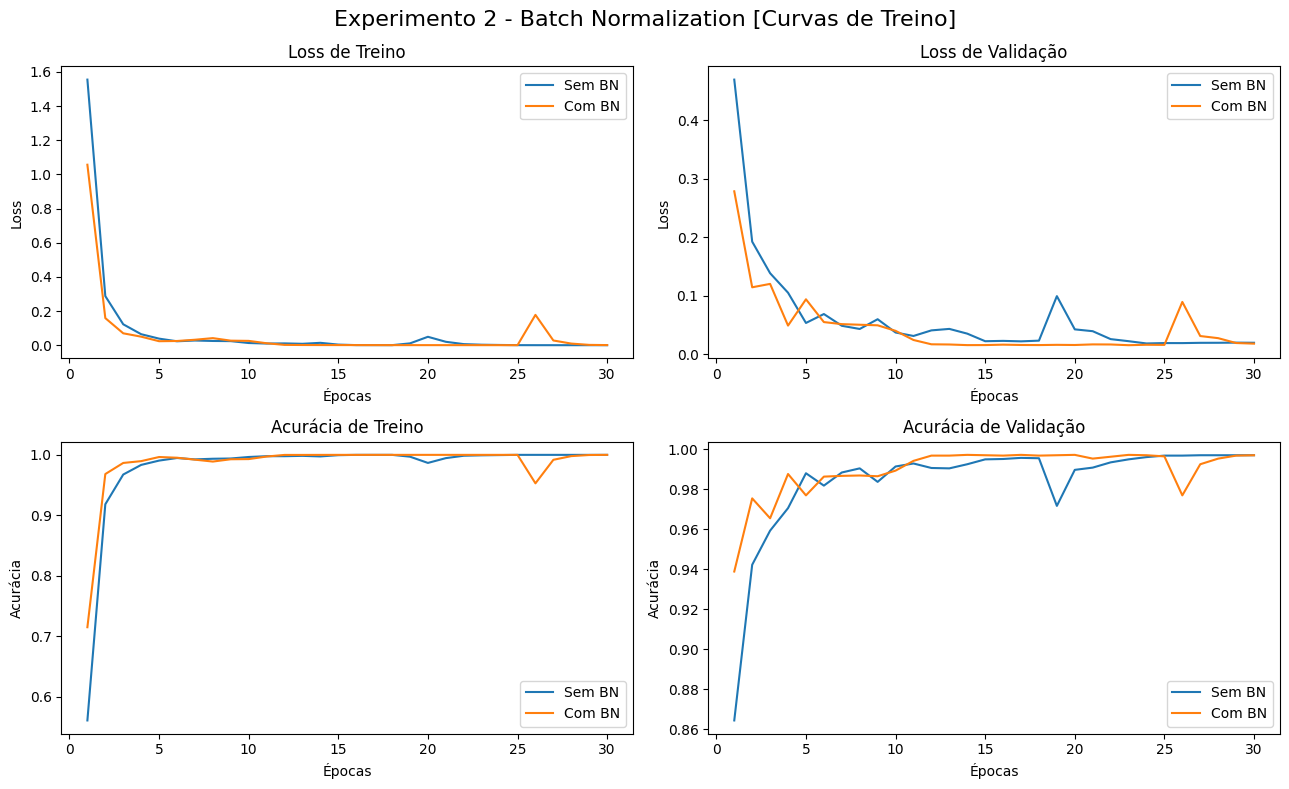

In [29]:
all_results = {"no_bn": res_no_bn, "bn": res_bn}
labels = {"no_bn": "Sem BN", "bn": "Com BN"}
colors = {"no_bn": "tab:blue", "bn": "tab:orange"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)

for name, r in all_results.items():
    axes[0, 0].plot(epochs, r["history"]["train_loss"], label=labels[name], color=colors[name])
axes[0, 0].set_title("Loss de Treino"); axes[0, 0].set_xlabel("Épocas"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

for name, r in all_results.items():
    axes[0, 1].plot(epochs, r["history"]["val_loss"], label=labels[name], color=colors[name])
axes[0, 1].set_title("Loss de Validação"); axes[0, 1].set_xlabel("Épocas"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend()

for name, r in all_results.items():
    axes[1, 0].plot(epochs, r["history"]["train_acc"], label=labels[name], color=colors[name])
axes[1, 0].set_title("Acurácia de Treino"); axes[1, 0].set_xlabel("Épocas"); axes[1, 0].set_ylabel("Acurácia"); axes[1, 0].legend()

for name, r in all_results.items():
    axes[1, 1].plot(epochs, r["history"]["val_acc"], label=labels[name], color=colors[name])
axes[1, 1].set_title("Acurácia de Validação"); axes[1, 1].set_xlabel("Épocas"); axes[1, 1].set_ylabel("Acurácia"); axes[1, 1].legend()

plt.suptitle("Experimento 2 - Batch Normalization [Curvas de Treino]", fontsize=16)
plt.tight_layout()
plt.savefig("figs2/curvas_treino_bn.png", dpi=150, bbox_inches="tight")
plt.show()


### 2. Matrizes de confusão dos dois modelos

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


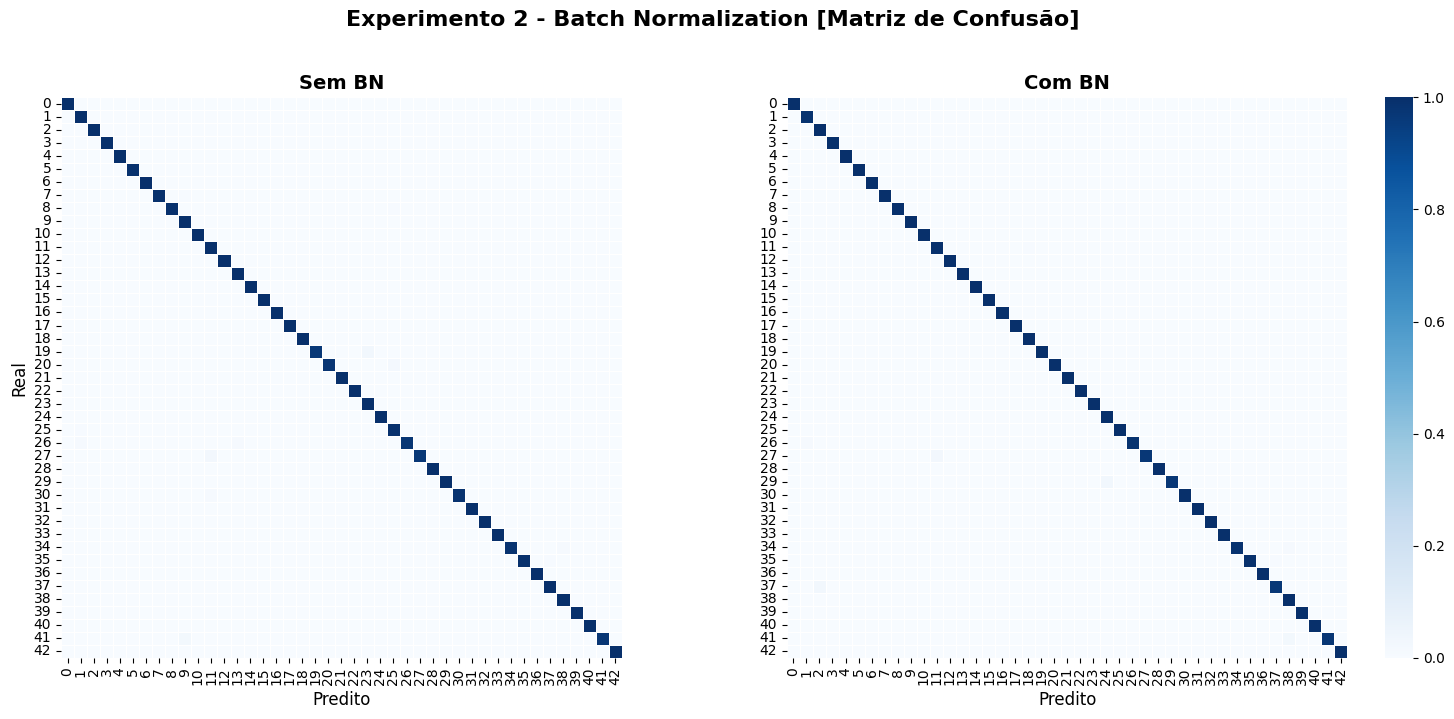

In [30]:
cm = {name: get_confusion_matrix(val_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
      for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, name in enumerate(["no_bn", "bn"]):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento 2 - Batch Normalization [Matriz de Confusão]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figs2/matrizes_confusao_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()


### 3. Acurácia por classe e macro accuracy

In [31]:
import pandas as pd

def relatorio_por_classe(cm, class_names=GTSRB_CLASSES, nome_modelo=""):
    """Calcula acurácia por classe (recall), acurácia global e macro accuracy.

    A matriz de confusão tem linhas = classe real e colunas = classe predita,
    então a acurácia de cada classe é diagonal / soma da linha.
    """
    cm = cm.numpy() if hasattr(cm, "numpy") else np.asarray(cm)
    suporte = cm.sum(axis=1)
    acertos = np.diag(cm)
    acc_classe = np.divide(acertos, suporte,
                           out=np.zeros(len(cm), dtype=float), where=suporte > 0)

    overall = acertos.sum() / cm.sum()
    macro_acc = acc_classe.mean()

    df = pd.DataFrame({
        "classe":   [class_names[i] for i in range(len(cm))],
        "suporte":  suporte.astype(int),
        "acertos":  acertos.astype(int),
        "acuracia": acc_classe.round(4),
    })

    print(f"=== {nome_modelo} ===")
    print(f"Acurácia global (overall): {overall:.4f}")
    print(f"Macro accuracy (média por classe): {macro_acc:.4f}\n")
    print("5 piores classes:")
    print(df.sort_values("acuracia").head(5).to_string(index=False))
    print()
    return df, overall, macro_acc

relatorios = {}
for name in ["no_bn", "bn"]:
    relatorios[name] = relatorio_por_classe(cm[name], nome_modelo=labels[name])


=== Sem BN ===
Acurácia global (overall): 0.9970
Macro accuracy (média por classe): 0.9954

5 piores classes:
               classe  suporte  acertos  acuracia
 Dangerous curve left       31       30    0.9677
          Pedestrians       34       33    0.9706
    End of no passing       40       39    0.9750
      Traffic signals       83       81    0.9759
Dangerous curve right       48       47    0.9792

=== Com BN ===
Acurácia global (overall): 0.9972
Macro accuracy (média por classe): 0.9957

5 piores classes:
             classe  suporte  acertos  acuracia
Go straight or left       29       28    0.9655
  Bicycles crossing       32       31    0.9688
        Pedestrians       34       33    0.9706
  End of no passing       40       39    0.9750
    Turn left ahead       68       67    0.9853



In [32]:
metrics_results = {}

for name, r in all_results.items():
    ytrue, ypred = predict(val_loader, r["model"], device)

    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())

    metrics_results[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }

    print(f"{labels[name]}:")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Sem BN:
  Acurácia Global: 0.9970
  Acurácia Macro:  0.9954

Com BN:
  Acurácia Global: 0.9972
  Acurácia Macro:  0.9957



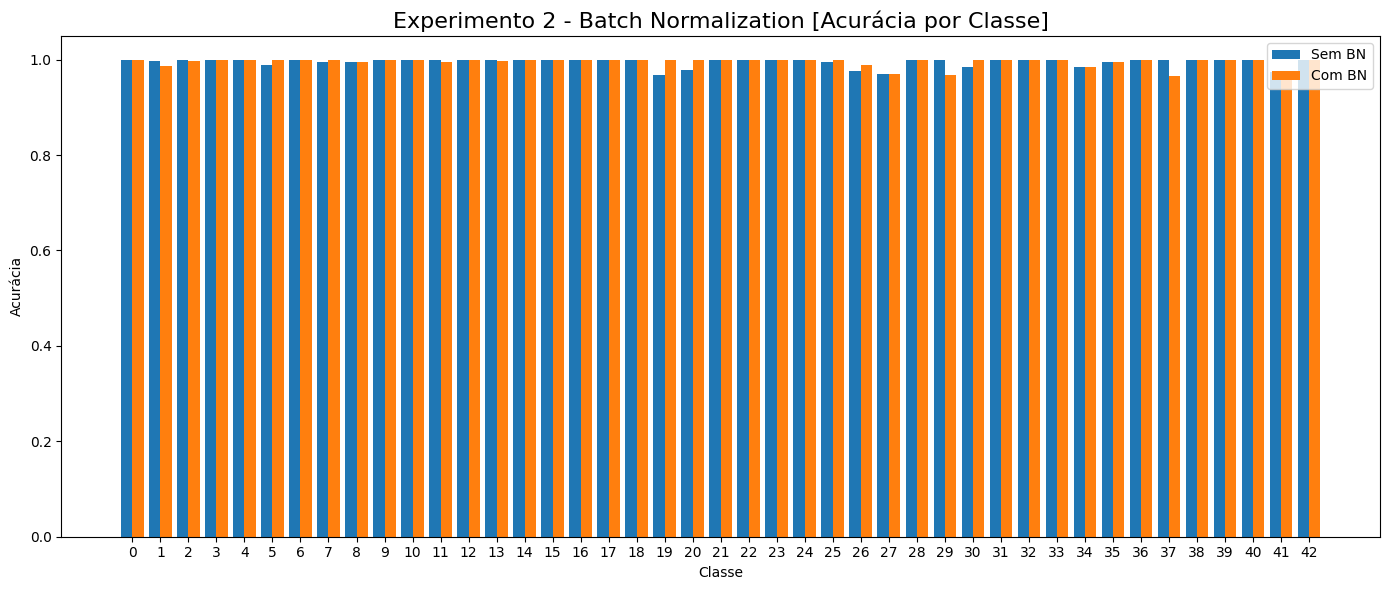

In [33]:
fig, ax = plt.subplots(figsize=(14, 6))
n_series = len(metrics_results)
width = 0.8 / n_series
x = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(metrics_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(x + offset, r["per_class_acc"], width=width, label=labels[name], color=colors[name])

ax.set_xlabel("Classe")
ax.set_ylabel("Acurácia")
ax.set_title("Experimento 2 - Batch Normalization [Acurácia por Classe]", fontsize=16)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig("figs2/acuracia_por_classe_bn.png", dpi=150, bbox_inches="tight")
plt.show()


### 4. Predições no conjunto de teste

In [34]:
def predict_test_set(test_loader, model, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            predictions.extend(preds)
    return predictions

y_pred_no_bn = predict_test_set(test_loader, all_results["no_bn"]["model"], device)
save_predictions(y_pred_no_bn, "predicoes_no_bn.csv", experiment_name="EHMNet sem BatchNorm")

y_pred_bn = predict_test_set(test_loader, all_results["bn"]["model"], device)
save_predictions(y_pred_bn, "predicoes_bn.csv", experiment_name="EHMNet com BatchNorm")


# Métricas oficiais no conjunto de TESTE (avaliação final)

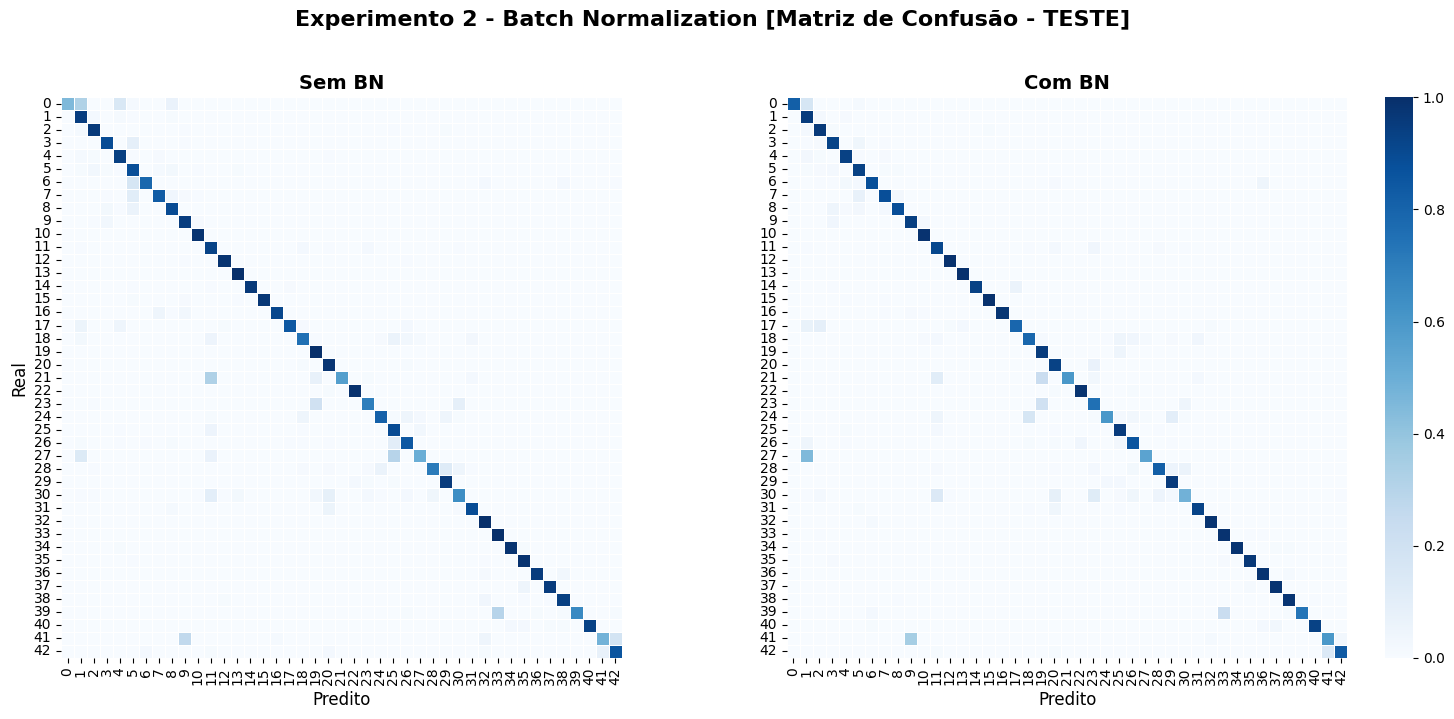

In [35]:
cm_test = {name: get_confusion_matrix(test_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
           for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, name in enumerate(["no_bn", "bn"]):
    cm_norm = cm_test[name].astype(float) / cm_test[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento 2 - Batch Normalization [Matriz de Confusão - TESTE]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figs2/matrizes_confusao_teste.png", dpi=150, bbox_inches="tight")
plt.show()


In [36]:
relatorios_teste = {}
for name in ["no_bn", "bn"]:
    relatorios_teste[name] = relatorio_por_classe(cm_test[name], nome_modelo=f"{labels[name]} (TESTE)")

metrics_results_teste = {}
for name, r in all_results.items():
    ytrue, ypred = predict(test_loader, r["model"], device)
    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())
    metrics_results_teste[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }
    print(f"{labels[name]} (TESTE):")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")

# Resumo comparando validacao x teste -- esse e o numero que vai pro relatorio
resumo_final = pd.DataFrame({
    "modelo": [labels["no_bn"], labels["bn"]],
    "acuracia_global_val":   [round(metrics_results["no_bn"]["global_acc"], 4), round(metrics_results["bn"]["global_acc"], 4)],
    "acuracia_global_teste": [round(metrics_results_teste["no_bn"]["global_acc"], 4), round(metrics_results_teste["bn"]["global_acc"], 4)],
    "macro_accuracy_val":    [round(metrics_results["no_bn"]["macro_acc"], 4), round(metrics_results["bn"]["macro_acc"], 4)],
    "macro_accuracy_teste":  [round(metrics_results_teste["no_bn"]["macro_acc"], 4), round(metrics_results_teste["bn"]["macro_acc"], 4)],
})
print(resumo_final.to_string(index=False))


=== Sem BN (TESTE) ===
Acurácia global (overall): 0.9080
Macro accuracy (média por classe): 0.8627

5 piores classes:
              classe  suporte  acertos  acuracia
Speed limit (20km/h)       60       27    0.4500
   End of no passing       60       29    0.4833
         Pedestrians       60       30    0.5000
        Double curve       90       51    0.5667
  Beware of ice/snow      150       96    0.6400

=== Com BN (TESTE) ===
Acurácia global (overall): 0.9193
Macro accuracy (média por classe): 0.8788

5 piores classes:
            classe  suporte  acertos  acuracia
Beware of ice/snow      150       73    0.4867
       Pedestrians       60       33    0.5500
Road narrows right       90       54    0.6000
      Double curve       90       54    0.6000
 End of no passing       60       36    0.6000



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Sem BN (TESTE):
  Acurácia Global: 0.9080
  Acurácia Macro:  0.8627

Com BN (TESTE):
  Acurácia Global: 0.9193
  Acurácia Macro:  0.8788

modelo  acuracia_global_val  acuracia_global_teste  macro_accuracy_val  macro_accuracy_teste
Sem BN               0.9970                 0.9080              0.9954                0.8627
Com BN               0.9972                 0.9193              0.9957                0.8788


### Overfetting --> comparação entre treino e validação

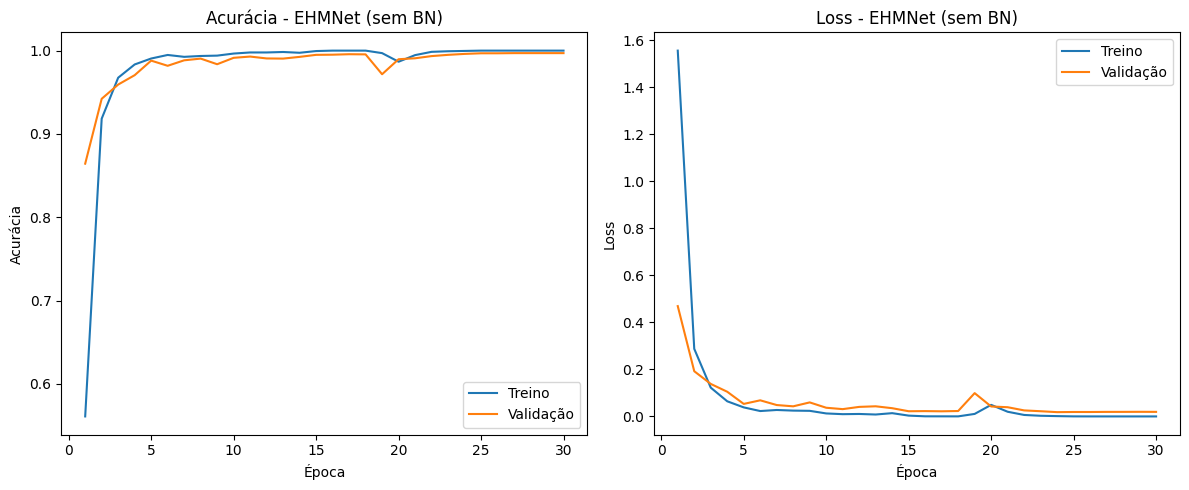

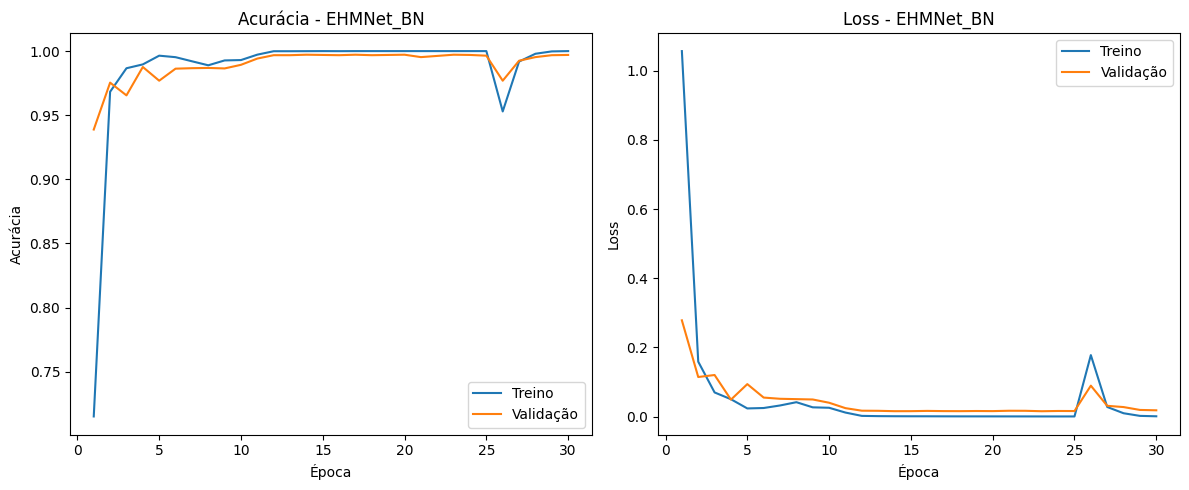

In [37]:
def plot_overfitting_check(history, model_name):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Treino')
    plt.plot(epochs, history['val_acc'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.title(f'Acurácia - {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Treino')
    plt.plot(epochs, history['val_loss'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"figs2/overfitting_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_check(res_no_bn["history"], "EHMNet (sem BN)")
plot_overfitting_check(res_bn["history"], "EHMNet_BN")


### (Opcional) Baixar os CSVs do Colab para a sua máquina

In [39]:
from google.colab import files
files.download('predicoes_no_bn.csv')
files.download('predicoes_bn.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>